In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# LabOne Q imports
from laboneq.simple import (
    Session,
    Experiment,
    ExperimentSignal,
    pulse_library,
    AcquisitionType,
    RepetitionMode,
    SectionAlignment,
    OutputSimulator,
)
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.simple import Calibration, SignalCalibration, Oscillator, ModulationType
from qubit import VirtualQubit
from BayesianEstimator import BayesianAdaptiveEstimator as bae

In [2]:
# Device setup

def make_session(): 
    """Create a LabOne Q device setup and session in emulation mode.

    Returns:
        (session, device_setup, q0) — the session, device descriptor, and qubit 0 object.
    """
    device_setup, qubits = generate_device_setup_qubits(
        number_qubits=1,
        pqsc=[{"serial": "DEV10001"}],
        hdawg=[{"serial": "DEV8001", "zsync": 0, "number_of_channels": 8, "options": None}],
        shfqc=[
            {
                "serial": "DEV12001",
                "zsync": 1,
                "number_of_channels": 6,
                "readout_multiplex": 6,
                "options": None,
            }
        ],
        include_flux_lines=True,
        server_host="localhost",
        setup_name="hackathon_singleQubit",
    )
    session = Session(device_setup)
    session.connect(do_emulation=True)
    q0 = qubits[0]
    return session, device_setup, q0

In [3]:
# Waveform extraction
def get_drive_waveform(
    session: Session,
    device_setup,
    q0,
    exp: Experiment,
    pulse_length: float,
):
    """Compile an experiment and extract the drive waveform envelope.

    Args:
        session:      Active LabOne Q session.
        device_setup: Device descriptor.
        q0:           Qubit object (LabOne Q).
        exp:          Experiment to compile.
        pulse_length: Duration [s] of the time axis to return.

    Returns:
        (t, wave) — time array starting at 0, complex envelope array.
    """
    compiled = session.compile(exp)
    drive_port = device_setup.logical_signal_by_uid(q0.uid + "/drive").physical_channel
    sim = OutputSimulator(compiled)
    snippet = sim.get_snippet(drive_port, start=0, output_length=pulse_length)
    t = snippet.time - snippet.time[0]   # ensure t[0] == 0
    return t, snippet.wave

In [4]:
# Experiment builders

def make_spec_experiment(q0, drive_freq: float, pulse_length: float = 2e-6,  amplitude=0.5):
    """Square-pulse spectroscopy experiment at a single drive frequency.

    Args:
        q0:          LabOne Q qubit object (for signal map).
        drive_freq:  Drive frequency [Hz] to set on the signal calibration.
        pulse_length: Duration of the square drive pulse [s].

    Returns:
        Configured (but not compiled) LabOne Q Experiment.
    """

    spec_pulse = pulse_library.const(uid="spec_pulse", length=pulse_length, amplitude=amplitude)

    exp = Experiment(
        uid="Spectroscopy",
        signals=[ExperimentSignal("drive")],
    )

    # Set calibration so the drive signal oscillates at drive_freq
    cal = Calibration()
    cal["drive"] = SignalCalibration(
        oscillator=Oscillator(
            frequency=drive_freq,
            modulation_type=ModulationType.HARDWARE,
        )
    )
    exp.set_calibration(cal)

    with exp.acquire_loop_rt(
        uid="shots",
        count=1,
        acquisition_type=AcquisitionType.SPECTROSCOPY,
        repetition_mode=RepetitionMode.CONSTANT,
        repetition_time=pulse_length + 500e-9,
    ):
        with exp.section(uid="drive_section"):
            exp.play(signal="drive", pulse=spec_pulse)

    exp.set_signal_map({"drive": q0.signals["drive"]})
    return exp

In [5]:
# Experiment builders

def make_rabi_experiment(q0, drive_freq: float, pulse_length: float = 2e-6,  amplitude=0.5):
    """gaussian-pulse spectroscopy experiment at a single drive frequency.

    Args:
        q0:          LabOne Q qubit object (for signal map).
        drive_freq:  Drive frequency [Hz] to set on the signal calibration.
        pulse_length: Duration of the square drive pulse [s].
        amplitude: 

    Returns:
        Configured (but not compiled) LabOne Q Experiment.
    """

    spec_pulse = pulse_library.gaussian(uid="gauss", length=pulse_length, amplitude=amplitude)

    exp = Experiment(
        uid="GaussianDrive",
        signals=[ExperimentSignal("drive")],
    )

    # Set calibration so the drive signal oscillates at drive_freq
    cal = Calibration()
    cal["drive"] = SignalCalibration(
        oscillator=Oscillator(
            frequency=drive_freq,
            modulation_type=ModulationType.HARDWARE,
        )
    )
    exp.set_calibration(cal)

    with exp.acquire_loop_rt(
        uid="shots",
        count=1,
        acquisition_type=AcquisitionType.SPECTROSCOPY,
        repetition_mode=RepetitionMode.CONSTANT,
        repetition_time=pulse_length + 500e-9,
    ):
        with exp.section(uid="drive_section"):
            exp.play(signal="drive", pulse=spec_pulse)

    exp.set_signal_map({"drive": q0.signals["drive"]})
    return exp

In [6]:
def lorentzian(f, f0, width, amplitude, offset):
    return offset + amplitude / (1 + ((f - f0) / (width / 2)) ** 2)


def fit_lorentzian(freqs: np.ndarray, P1: np.ndarray) -> float:
    """Fit a Lorentzian peak to spectroscopy data and return the centre frequency."""
    f0_guess = freqs[np.argmax(P1)]
    width_guess = (freqs[-1] - freqs[0]) / 10
    amp_guess = np.max(P1) - np.min(P1)
    offset_guess = np.min(P1)
    popt, pcov = curve_fit(
        lorentzian, freqs, P1,
        p0=[f0_guess, width_guess, amp_guess, offset_guess],
        maxfev=10000,
    )
    return popt[0], float(np.sqrt(pcov[0, 0]))

def voigt(f, f0, sigma, gamma, amp, offset):
    """Voigt profile = Gaussian (instrument) (x) Lorentzian (qubit line).
 
    Args:
        f0:    centre frequency
        sigma: Gaussian std (instrument response, set by pulse spectrum)
        gamma: Lorentzian HWHM (intrinsic qubit linewidth ~ 1/(2 pi T2))
        amp:   peak amplitude (the value at f=f0 minus offset, BEFORE
               normalisation -- we multiply scipy's normalised profile
               by amp / V(0; sigma, gamma) so this stays a true peak height)
        offset: baseline
    """
    profile = voigt_profile(f - f0, sigma, gamma)
    peak = voigt_profile(0.0, sigma, gamma)
    return offset + amp * profile / peak
    
def fit_voigt(freqs, P1, sigma_init=None):
    """Voigt fit. sigma_init: initial Gaussian sigma in Hz (~pulse-spectral width)."""
    f0_g = freqs[np.argmax(P1)]
    span = freqs[-1] - freqs[0]
    if sigma_init is None:
        sigma_init = span / 100
    p0 = [f0_g, sigma_init, sigma_init * 0.5,
          np.max(P1) - np.min(P1), np.min(P1)]
    bounds = (
        [freqs[0],  span * 1e-5, 0.0,  0,    -0.1],
        [freqs[-1], span * 0.5,  span, 1.5,   1.0],
    )

    popt, pcov = curve_fit(voigt, freqs, P1, p0=p0, bounds=bounds,
                           maxfev=20000)
    f0, f0_err = popt[0], float(np.sqrt(pcov[0, 0]))
    rms = float(np.sqrt(np.mean((P1 - voigt(freqs, *popt)) ** 2)))  # unpack popt; ** not *
    return f0, f0_err

def sinusoid(x, A, omega, phi, offset):
    return offset + A * np.sin(omega * x + phi)


def fit_sinusoid(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float, float]:
    """Fit a sinusoid and return (A, omega, phi, offset)."""
    A_guess = (np.max(y) - np.min(y)) / 2
    offset_guess = np.mean(y)
    # Rough frequency estimate via FFT
    fft = np.abs(np.fft.rfft(y - offset_guess))
    freqs = np.fft.rfftfreq(len(x), d=(x[1] - x[0]))
    omega_guess = 2 * np.pi * freqs[np.argmax(fft[1:]) + 1]
    try:
        popt, _ = curve_fit(
            sinusoid, x, y,
            p0=[A_guess, omega_guess, 0, offset_guess],
            maxfev=10000,
        )
        return popt
    except RuntimeError:
        return A_guess, omega_guess, 0.0, offset_guess


def exponential_decay(t, A, T1, offset):
    return offset + A * np.exp(-t / T1)


def fit_T1(delays: np.ndarray, P1: np.ndarray) -> float:
    """Fit exponential decay to T1 data, return T1 [s]."""
    try:
        popt, _ = curve_fit(
            exponential_decay, delays, P1,
            p0=[np.max(P1), 30e-6, np.min(P1)],
            maxfev=10000,
        )
        return popt[1]
    except RuntimeError:
        print("  [warn] T1 fit failed, returning rough estimate")
        return delays[np.argmax(P1 < 0.5 * np.max(P1))]
    
def ramsey_decay(t, A, T2, omega, phi, offset):
    """Exponentially decaying sinusoid for Ramsey fringe fitting.
    
    P(t) = offset + A * exp(-t / T2) * sin(omega * t + phi)
    
    Args:
        t:      Free-precession delay [s].
        A:      Fringe amplitude.
        T2:     Dephasing time [s]  ← what we want to extract.
        omega:  Angular fringe frequency [rad/s] = 2π * detuning_measured.
        phi:    Phase offset [rad].
        offset: Baseline (~0.5 for a perfect π/2 pulse).
    """
    return offset + A * np.exp(-t / T2) * np.sin(omega * t + phi)


def fit_ramsey(delays, P1):
    """Fit a decaying sinusoid to Ramsey data.

    Returns:
        f_fringe : fringe oscillation frequency [Hz]
        T2       : fitted dephasing time [s]
        T2_err   : 1-sigma uncertainty on T2 [s]
        popt     : full parameter array [A, T2, omega, phi, offset]
        pcov     : covariance matrix
    """
    # Seed omega from FFT of the mean-subtracted signal
    A_guess      = (np.max(P1) - np.min(P1)) / 2
    offset_guess = np.mean(P1)
    fft_mag      = np.abs(np.fft.rfft(P1 - offset_guess))
    fft_freq     = np.fft.rfftfreq(len(delays), d=float(delays[1] - delays[0]))
    omega_guess  = 2 * np.pi * fft_freq[np.argmax(fft_mag[1:]) + 1]

    # T2 seed: use the full delay span / 3 as a conservative guess
    T2_guess = float(delays[-1]) / 3

    p0 = [A_guess, T2_guess, omega_guess, 0.0, offset_guess]

    bounds = (
        [0,       1e-8,  omega_guess * 0.5, -np.pi, 0.0],
        [1.0,     1e-2,  omega_guess * 2.0,  np.pi, 1.0],
    )

    try:
        popt, pcov = curve_fit(
            ramsey_decay, delays, P1,
            p0=p0, bounds=bounds, maxfev=20000,
        )
        A, T2, omega_fit, phi, offset = popt
        T2_err   = float(np.sqrt(pcov[1, 1]))
        f_fringe = omega_fit / (2 * np.pi)
        return f_fringe, T2, T2_err, popt, pcov
    except RuntimeError:
        print("  [warn] Ramsey fit failed, returning FFT estimate")
        return omega_guess / (2 * np.pi), T2_guess, np.nan, p0, None


In [7]:
def qubit_spectroscopy(
    virtual_qubit: VirtualQubit,
    session: Session,
    device_setup,
    q0_loneq,
    freq_start: float = 5.0e9,
    freq_stop: float = 6.2e9,
    n_points: int = 101,
    shots: int = 2000,
    pulse_length: float = 2e-6,
    fit_type: str = "voigt"
):
    """Sweep drive frequency and measure excited-state population.

    Args:
        virtual_qubit: The VirtualQubit to drive and measure.
        session:       LabOne Q session.
        device_setup:  Device descriptor.
        q0_loneq:      LabOne Q qubit object.
        freq_start:    Sweep start frequency [Hz].
        freq_stop:     Sweep stop frequency [Hz].
        n_points:      Number of frequency points.
        shots:         Measurement shots per frequency.
        pulse_length:  Square pulse duration [s].

    Returns:
        (freqs, P1) — frequency array and excited-state probabilities.
    """
    freqs = np.linspace(freq_start, freq_stop, n_points)
    P1 = []

    print(f"  Spectroscopy: sweeping {n_points} frequencies from {freq_start/1e9:.2f} to {freq_stop/1e9:.2f} GHz")

    for f in freqs:
        if fit_type == "voigt":
            exp = make_rabi_experiment(q0_loneq, drive_freq=f, pulse_length=pulse_length)
        elif fit_type == "lorentzian":
            exp = make_spec_experiment(q0_loneq, drive_freq=f, pulse_length=pulse_length)
       
        t, wave = get_drive_waveform(session, device_setup, q0_loneq, exp, pulse_length)

        virtual_qubit.reset()
        virtual_qubit.evolve(t, wave, drive_freq=f)
        bits = virtual_qubit.measure(shots=shots)
        P1.append(bits.mean())

    if fit_type == "voigt":
        f_q, f_err = fit_voigt(freqs, P1)
    elif fit_type == "lorentzian":
        f_q, f_err = fit_lorentzian(freqs, P1)
        
    print(f"  → f_q (spectroscopy) = {f_q / 1e9:.5f} GHz")

    return freqs, np.array(P1), f_q, f_err

In [8]:
def amplitude_rabi_ramsey(
    virtual_qubit: VirtualQubit,
    session: Session,
    device_setup,
    q0_loneq,
    drive_freq: float,
    amp_start: float = 0.01,
    amp_stop: float = 4.0,
    n_points: int = 51,
    shots: int = 2000,
    pulse_length: float = 100e-9,
):
    """Sweep pulse amplitude and fit Rabi oscillations to find π and π/2 amplitudes.

    Args:
        virtual_qubit: The VirtualQubit to drive and measure.
        session:       LabOne Q session.
        device_setup:  Device descriptor.
        q0_loneq:      LabOne Q qubit object.
        drive_freq:    Resonance frequency to drive at [Hz].
        amp_start:     Sweep start amplitude.
        amp_stop:      Sweep stop amplitude.
        n_points:      Number of amplitude points.
        shots:         Measurement shots per amplitude.
        pulse_length:  Gaussian pulse duration [s].

    Returns:
        (amp_pi, amp_pi2) — π and π/2 pulse amplitudes.
    """
    amps = np.linspace(amp_start, amp_stop, n_points)
    P1 = []

    print(f"  Amplitude Rabi: sweeping {n_points} amplitudes")

    for amp in amps:
        exp = make_rabi_experiment(q0_loneq, amplitude=amp, pulse_length=pulse_length, drive_freq=drive_freq)
        t, wave = get_drive_waveform(session, device_setup, q0_loneq, exp, pulse_length)

        virtual_qubit.reset()
        virtual_qubit.evolve(t, wave, drive_freq=drive_freq)
        bits = virtual_qubit.measure(shots=shots)
        P1.append(bits.mean())

    
    P1 = np.array(P1)
    A, omega, phi, offset = fit_sinusoid(amps, P1)

    amp_pi = (np.pi / 2 - phi) / omega

    if ((np.pi - phi)) > 0:
        amp_pi2 = -phi / omega
    amp_pi2 = (np.pi - phi) / omega
    return amps, P1, float(amp_pi), float(amp_pi2)


In [9]:
def measure_T1_adaptive(
    virtual_qubit: VirtualQubit,
    session: Session,
    device_setup,
    q0_loneq,
    drive_freq: float,
    amp_pi: float,
    pulse_length: float = 100e-9,
    shots: int = 1,
):
    """Apply π pulse, wait variable delay, measure — fit exponential to get T1.

    Args:
        virtual_qubit: The VirtualQubit.
        session:       LabOne Q session.
        device_setup:  Device descriptor.
        q0_loneq:      LabOne Q qubit object.
        drive_freq:    Qubit resonance frequency [Hz].
        amp_pi:        Calibrated π-pulse amplitude.
        evolve_start:   Shortest wait delay [s].
        evolve_stop:    Longest wait delay [s].
        n_points:      Number of delay points.
        shots:         Measurement shots per delay.
        pulse_length:  Duration of the π pulse [s].

    Returns:
        Fitted T1 relaxation time [s].
    """

    # Build the π-pulse waveform once (reuse across delays)
    exp_pi = make_rabi_experiment(q0_loneq, amplitude=amp_pi, pulse_length=pulse_length, drive_freq= drive_freq)
    t_pi, wave_pi = get_drive_waveform(session, device_setup, q0_loneq, exp_pi, pulse_length)

    est = bae("exponential", T1_prior_mean=30e-6, confidence_target=0.10)

    counts = 0
    while not est.has_converged() or counts < 1000:
        tau = est.next_x()                                  # seconds, safe for mesolve
        virtual_qubit.reset()
        virtual_qubit.evolve(t_pi, wave_pi, drive_freq=drive_freq)
        virtual_qubit.wait(drive_freq, tau)                        # tau in seconds ✓
        bit = virtual_qubit.measure(shots=shots)                # numpy array ✓
        est.update(tau, bit)                                # auto-coerced ✓
        counts += 1

    T1 = est.result().estimates[0]   # seconds

    return T1, counts


In [10]:
# --- Virtual qubit (physics simulator) ---
print("\n[INIT] Creating virtual qubit (seed=42)...")
virtual_qubit = VirtualQubit(seed=42)

# --- LabOne Q hardware (emulated) ---
print("[INIT] Setting up LabOne Q session (emulation mode)...")
session, device_setup, q0_loneq = make_session()

/Users/bhoomikatanikonda/Desktop/eqh/ZturingMachine/.venv/lib/python3.11/site-packages/laboneq/contrib/example_helpers/generate_device_setup.py:660: FutureWarning: Deprecated option `zsync` provided for instrument DEV8001 - ZSync information is queried from instruments by default.
  device_setup = generate_device_setup(
/Users/bhoomikatanikonda/Desktop/eqh/ZturingMachine/.venv/lib/python3.11/site-packages/laboneq/contrib/example_helpers/generate_device_setup.py:660: FutureWarning: Deprecated option `zsync` provided for instrument DEV12001 - ZSync information is queried from instruments by default.
  device_setup = generate_device_setup(



[INIT] Creating virtual qubit (seed=42)...
[INIT] Setting up LabOne Q session (emulation mode)...
[2026.05.10 10:14:53.819] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/bhoomikatanikonda/Desktop/eqh/ZturingMachine/laboneq_output/log
[2026.05.10 10:14:53.821] INFO    VERSION: laboneq 26.4.0
[2026.05.10 10:14:53.822] INFO    Connecting to data server at localhost:8004
[2026.05.10 10:14:53.822] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.0.940 at localhost:8004
[2026.05.10 10:14:53.824] INFO    Configuring the device setup
[2026.05.10 10:14:53.849] INFO    The device setup is configured



[STEP 1] Qubit Spectroscopy
  Spectroscopy: sweeping 401 frequencies from 5.00 to 6.00 GHz
[2026.05.10 10:14:53.866] INFO    Starting LabOne Q Compiler run...
[2026.05.10 10:14:53.867] INFO    Schedule completed. [0.000 s]
[2026.05.10 10:14:53.871] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.05.10 10:14:53.871] INFO    Completed compilation step 1 of 1. [0.005 s]
[2026.05.10 10:14:53.875] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:14:53.875] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.05.10 10:14:53.875] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:14:53.875] INFO      shfqc_0_sg     0          9            2           1      8000  
[2026.05.10 10:14:53.876] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:14:53.876] INFO      TOTAL                     9            2                  8000  
[2026.0

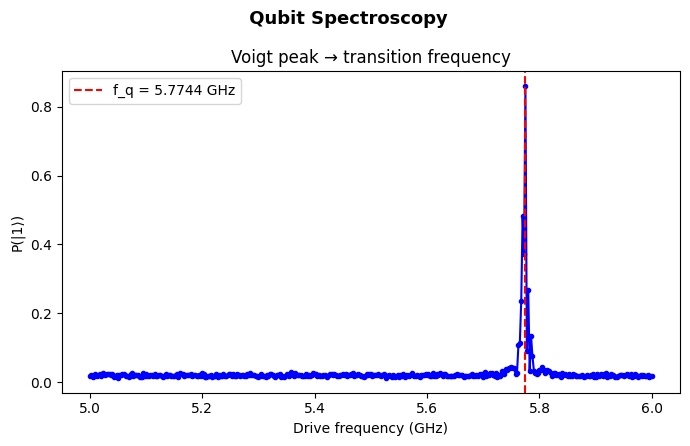

In [11]:
# --------------------------------------------------------
# STEP 1: Qubit Spectroscopy
# --------------------------------------------------------
print("\n[STEP 1] Qubit Spectroscopy")
freqs, P1_spec, f_q, f_err= qubit_spectroscopy(
    virtual_qubit, session, device_setup, q0_loneq,
    freq_start=5e9, freq_stop=6e9, n_points=401,
    shots=2000, pulse_length=2e-6, fit_type= "lorentzian"
)
print(f"  → Transition frequency: f_q = {f_q/1e9:.7f} GHz")
print(f"  → error in Transition frequency: f_err = {f_err/1e9:.7f} GHz")
print(max(P1_spec))
# plot
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle(" Qubit Spectroscopy", fontsize=13, fontweight="bold")
ax.plot(freqs / 1e9, P1_spec, "b.-")
ax.axvline(f_q / 1e9, color="red", linestyle="--", label=f"f_q = {f_q/1e9:.4f} GHz")
ax.set_xlabel("Drive frequency (GHz)")
ax.set_ylabel("P(|1⟩)")
ax.set_title("Voigt peak → transition frequency")
ax.legend()
plt.tight_layout()
plt.savefig("step1_spectroscopy.png", dpi=150)
plt.show()


[STEP 2] Amplitude Rabi
  Amplitude Rabi: sweeping 51 amplitudes
[2026.05.10 10:15:38.389] INFO    Starting LabOne Q Compiler run...
[2026.05.10 10:15:38.393] INFO    Schedule completed. [0.000 s]
[2026.05.10 10:15:38.394] INFO    Code generation completed for all AWGs. [0.001 s]
[2026.05.10 10:15:38.397] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.05.10 10:15:38.401] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:15:38.403] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.05.10 10:15:38.404] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:15:38.404] INFO      shfqc_0_sg     0          9            2           1       416  
[2026.05.10 10:15:38.405] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:15:38.409] INFO      TOTAL                     9            2                   416  
[2026.05.10 10:15:38.409] INFO   

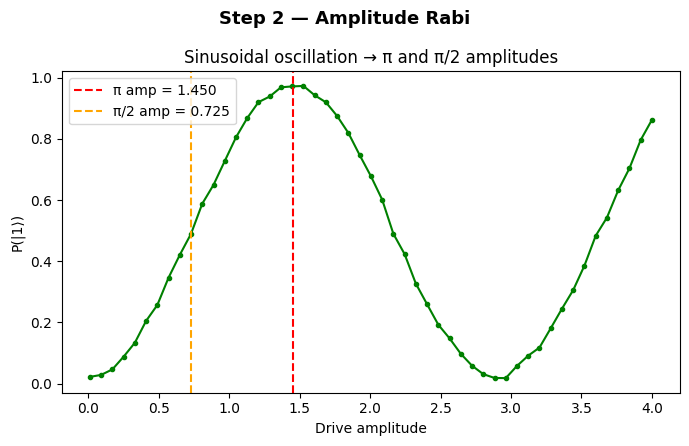

In [12]:
# --------------------------------------------------------
# STEP 2: Amplitude Rabi
# --------------------------------------------------------
print("\n[STEP 2] Amplitude Rabi")

amps, P1_rabi, amp_pi, amp_pi2 = amplitude_rabi_ramsey(
    virtual_qubit, session, device_setup, q0_loneq,
    drive_freq= f_q,
    amp_start= 0.01,
    amp_stop = 4.0,
    n_points = 51,
    shots = 2000,
    pulse_length = 100e-9,
)
print(f"  → π-pulse amplitude:    amp_π  = {amp_pi:.4f}")
print(f"  → π/2-pulse amplitude:  amp_π₂ = {amp_pi2:.4f}")

# plot
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle("Step 2 — Amplitude Rabi", fontsize=13, fontweight="bold")
ax.plot(amps, P1_rabi, "g.-")
ax.axvline(amp_pi, color="red", linestyle="--", label=f"π amp = {amp_pi:.3f}")
ax.axvline(amp_pi / 2, color="orange", linestyle="--", label=f"π/2 amp = {amp_pi/2:.3f}")
ax.set_xlabel("Drive amplitude")
ax.set_ylabel("P(|1⟩)")
ax.set_title("Sinusoidal oscillation → π and π/2 amplitudes")
ax.legend()
plt.tight_layout()
plt.savefig("step2_rabi.png", dpi=150)
plt.show()


In [13]:
# --------------------------------------------------------
# STEP 3: T1 Measurement
# --------------------------------------------------------
print("\n[STEP 3] T1 Measurement")

T1, counts = measure_T1_adaptive(
    virtual_qubit, session, device_setup, q0_loneq,
    drive_freq = f_q,
    amp_pi = amp_pi,
    pulse_length = 100e-9,
    shots = 20)


print(f"  → T1 = {T1*1e6:.1f} µs")
print(f"  → counts = {counts}")



[STEP 3] T1 Measurement
[2026.05.10 10:15:40.233] INFO    Starting LabOne Q Compiler run...
[2026.05.10 10:15:40.236] INFO    Schedule completed. [0.000 s]
[2026.05.10 10:15:40.239] WARNING Pulse 'gauss' on signal drive exceeds the max allowed amplitude. Signal will be clipped on the device.
[2026.05.10 10:15:40.240] WARNING A waveform on signal 'drive' exceeds the max allowed amplitude. Signal will be clipped on the device.
[2026.05.10 10:15:40.242] INFO    Code generation completed for all AWGs. [0.004 s]
[2026.05.10 10:15:40.243] INFO    Completed compilation step 1 of 1. [0.006 s]
[2026.05.10 10:15:40.249] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:15:40.250] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.05.10 10:15:40.251] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 10:15:40.251] INFO      shfqc_0_sg     0          9            2           1       416  
[20